# 3. Public-hull derivatives and added mass

Notebooks 1 and 2 used one canonical shape and one hull. This notebook runs the
same pipeline across five public geometries — **KCS**, **KVLCC2**,
**DTMB 5415**, **DTC** and the analytic **Wigley** hull — to answer three
questions that a single case cannot:

1. Do the geometry importers produce closed, correctly oriented, correctly
   scaled hulls from four completely different public file formats?
2. How large is the strict-Wang yaw approximation error on real hulls, as a
   function of how slender they are?
3. How do the zero-frequency added masses and static-drift derivatives compare
   with published captive-test and empirical values?

Run `validation/public_hulls/fetch_geometry.sh` once before executing. All
downloaded geometry lands in an untracked `data/` directory and all figures in
an untracked `results/` directory; nothing large enters version control.

In [1]:
using Pkg

function marinehydro_root(start=pwd())
    directory = abspath(start)
    while true
        project = joinpath(directory, "Project.toml")
        if isfile(project) && occursin("name = \"MarineHydro\"", read(project, String))
            return directory
        end
        parent = dirname(directory)
        parent == directory && error("Run Jupyter from the MarineHydro.jl repository.")
        directory = parent
    end
end

project_root = marinehydro_root()
Pkg.activate(project_root)

using Revise
using MarineHydro
using CairoMakie
using TOML
CairoMakie.activate!()

validation_directory = joinpath(project_root, "validation", "public_hulls")
results_directory = joinpath(validation_directory, "results")
mkpath(results_directory)
reference_table = TOML.parsefile(joinpath(validation_directory, "references.toml"))

  Activating project at `c:\Users\iamje\.julia\dev\MarineHydro`


Dict{String, Any} with 5 entries:
  "KCS"      => Dict{String, Any}("reference_J_z_prime"=>0.009268, "schmitz_x_o…
  "KVLCC2"   => Dict{String, Any}("reference_J_z_prime"=>0.011, "schmitz_x_over…
  "Wigley"   => Dict{String, Any}("reference_J_z_prime"=>"NaN", "schmitz_x_over…
  "DTC"      => Dict{String, Any}("reference_J_z_prime"=>"NaN", "schmitz_x_over…
  "DTMB5415" => Dict{String, Any}("reference_J_z_prime"=>"NaN", "schmitz_x_over…

## 3.1 Four geometry formats, one internal convention

Public hull geometry arrives in whatever format the originating workshop used.
MarineHydro normalises all of them to its own convention — $x$ forward with the
origin amidships, $y$ to port, $z$ up with the origin at the undisturbed
waterline, panel normals pointing from the body into the fluid.

| Hull | Public source | Importer |
|---|---|---|
| KCS, KVLCC2 | NMRI Gothenburg-workshop structured surfaces (Tecplot) | `read_gothenburg2010_mesh` |
| DTMB 5415 | Official formatted Plot3D surface (`5415_static.net`) | `read_plot3d_structured_surfaces` → `structured_surface_waterline_mesh` |
| DTC | Public OpenFOAM ASCII STL | `read_ascii_stl_waterline_mesh` |
| Wigley | Analytic: $y = \tfrac{B}{2}\big[1-(2x/L)^2\big]\big[1-(z/T)^2\big]$ | `wigley_hull_mesh` |

Three operations are shared by all four paths and are where hull importers
normally go wrong:

* **Exact waterline clipping.** Panels straddling $z=0$ are cut at $z=0$, not
  discarded or kept whole. Without this the displaced volume is wrong by a
  whole panel row.
* **Consistent orientation.** `interior_point` is supplied so every panel normal
  can be flipped to point outward. A single inverted panel corrupts the
  boundary condition and the added mass.
* **Mirroring.** Sources that define one side are reflected to give a
  symmetric mesh.

The Wigley hull is included specifically because it is *analytic*: its
displaced volume is $\nabla = \tfrac{4}{9}LBT$ exactly, so any importer or
quadrature error shows up immediately with no reference-data uncertainty.

In [2]:
"""
    public_hull_cases(; fine=false)

Construct the five benchmark meshes in MarineHydro's x-forward, y-port, z-up
convention. `fine=false` keeps every hull below roughly 500 panels, which is
appropriate for interactive work; `fine=true` refines each source for a
convergence check.
"""
function public_hull_cases(;
    fine::Bool=false,
    data_directory=joinpath(validation_directory, "data"),
    gothenburg_data=joinpath(project_root, "validation", "gothenburg2010", "data"),
)
    require_file(path) = isfile(path) ? path :
        error("Missing geometry $(path). Run validation/public_hulls/fetch_geometry.sh.")

    gothenburg_shape = fine ? (18, 10) : (14, 8)
    dtmb_shape = fine ? (37, 13) : (29, 11)
    dtc_clustering = fine ? (24, 8, 5) : (18, 6, 4)
    wigley_shape = fine ? (32, 8) : (24, 6)

    function gothenburg_paths(hull)
        filenames = hull == "KCS" ? ("kcs_bow1.dat", "kcs_stn1.dat") :
                                    ("kvlcc_bow1.dat", "kvlcc2_stn1.dat")
        return collect(require_file.(joinpath.(joinpath(gothenburg_data, hull), filenames)))
    end

    meshes = Dict{String,Any}()
    for hull in ("KCS", "KVLCC2")
        meshes[hull] = read_gothenburg2010_mesh(
            gothenburg_paths(hull);
            length_scale=reference_table[hull]["length_m"],
            target_shape=gothenburg_shape,
        )
    end

    dtmb = reference_table["DTMB5415"]
    dtmb_surface = only(read_plot3d_structured_surfaces(require_file(
        joinpath(data_directory, "DTMB5415", "5415_static.net"),
    )))
    meshes["DTMB5415"] = structured_surface_waterline_mesh(
        dtmb_surface;
        target_shape=dtmb_shape,
        mirror=true,
        coordinate_transform=point -> [
            point[1] - dtmb["length_m"] / 2, -point[2], point[3] - dtmb["draft_m"],
        ],
        interior_point=[0.0, 0.0, -dtmb["draft_m"] / 2],
    )

    dtc = reference_table["DTC"]
    meshes["DTC"] = read_ascii_stl_waterline_mesh(
        require_file(joinpath(data_directory, "DTC", "DTC-scaled.stl"));
        clustering=dtc_clustering,
        coordinate_transform=point -> [
            point[1] - dtc["length_m"] / 2, -point[2], point[3] - dtc["draft_m"],
        ],
        interior_point=[0.0, 0.0, -dtc["draft_m"] / 2],
    )

    wigley = reference_table["Wigley"]
    meshes["Wigley"] = wigley_hull_mesh(
        wigley["length_m"], wigley["beam_m"], wigley["draft_m"];
        longitudinal_panels=wigley_shape[1], vertical_panels=wigley_shape[2],
    )

    labels = Dict("KCS" => "KCS", "KVLCC2" => "KVLCC2",
                  "DTMB5415" => "DTMB 5415", "DTC" => "DTC", "Wigley" => "Wigley")
    return [(id=id, name=labels[id], mesh=meshes[id], reference=reference_table[id])
            for id in ("KCS", "KVLCC2", "DTMB5415", "DTC", "Wigley")]
end

cases = public_hull_cases()
for case in cases
    reference = case.reference
    volume = mesh_signed_volume(case.mesh)
    println((case.name, panels=case.mesh.nfaces,
             volume, published_volume=reference["displacement_m3"],
             volume_error=volume / reference["displacement_m3"] - 1,
             beam_over_length=reference["beam_m"] / reference["length_m"]))
end

(name = "KCS", panels = 364, volume = 0.06618651682781396, published_volume = 0.06686902173913042, volume_error = -0.010206593330751246, beam_over_length = 0.13999999999999999)
(name = "KVLCC2", panels = 364, volume = 0.147543436702912, published_volume = 0.14906978607177734, volume_error = -0.010239159853160262, beam_over_length = 0.18125)
(name = "DTMB 5415", panels = 462, volume = 0.548167044496246, published_volume = 0.554, volume_error = -0.010528800548292527, beam_over_length = 0.13426573426573427)
(name = "DTC", panels = 479, volume = 0.797874169514987, published_volume = 0.827, volume_error = -0.035218658385747226, beam_over_length = 0.14374163319946454)
(name = "Wigley", panels = 288, volume = 0.042981866145163285, published_volume = 0.043333333333333335, volume_error = -0.008110781265462719, beam_over_length = 0.1)


## 3.2 What is being compared, and in which normalization

**Added mass** is the strong target. It follows directly from the
zero-frequency potential with no empirical ingredient at all, so a disagreement
is a real disagreement. Two normalizations appear below:

$$m_y' = \frac{A_{22}}{\tfrac12\rho L^2 T},\qquad
J_z' = \frac{A_{66}}{\tfrac12\rho L^4 T},\qquad
\frac{A_{22}}{\rho\nabla}\ \text{(displacement-based)} .$$

The last one is used because it is the form in which an approximate DTC
deep-water value is published.

**Static-drift derivatives** are the weak target. As established in notebook 1,
ideal flow gives $Y_v = 0$ identically, so the numbers below owe their entire
magnitude to the Schmitz stern cut recorded per hull in `references.toml`. In
MMG convention the drift angle is $\beta$ with $v = -U\sin\beta$, so

$$Y_\beta' = -Y_v'\big|_{MMG} = -\frac{L}{T}\,Y_v'\big|_{W},
\qquad N_\beta' = -\frac{L}{T}\,N_v'\big|_{W},$$

which is the conversion applied below. Captive-test slopes also contain
viscous cross-flow and finite-Froude-number effects that a double-body model
does not have, so agreement here is weaker evidence than agreement on added
mass.

Both yaw treatments are evaluated on the same solve: the independent yaw
potential $\phi_r$ and the strict-Wang approximation $x\,\phi_2$.

In [3]:
"""
    analyze_public_hull(case; density=1025, forward_speed=1)

Solve independent sway and yaw potentials, apply the hull's Schmitz stern cut to
the velocity integrals only, and return geometry, derivative and added-mass
comparison metrics. Acceleration derivatives always use the complete wetted
surface.
"""
function analyze_public_hull(case; density::Real=1025.0, forward_speed::Real=1.0)
    reference = case.reference
    hull_length = reference["length_m"]
    draft = reference["draft_m"]
    displacement = reference["displacement_m3"]
    velocity_mask = wang_stern_mask(
        case.mesh, reference["schmitz_x_over_length"] * hull_length,
    )

    exact = solve_potential_flow_maneuvering(
        case.mesh, forward_speed; rho=density, velocity_mask,
    )
    strict = wang_hydrodynamic_derivatives(
        case.mesh, exact.potentials.sway, exact.potential_gradients.sway[:, 1],
        forward_speed; rho=density, velocity_mask,
    )
    # `exact.potentials` always holds the indirect solution, and
    # `wang_hydrodynamic_derivatives` above is built from it. Comparing the
    # strict yaw approximation against the direct-formulation result would
    # therefore mix two independent effects, so the strict-versus-independent
    # comparison below is evaluated entirely within the indirect formulation.
    indirect_reference = potential_flow_hydrodynamic_derivatives(
        case.mesh, exact.potentials.sway, exact.potentials.yaw,
        exact.potential_gradients.sway[:, 1],
        exact.potential_gradients.yaw[:, 1],
        forward_speed; rho=density, velocity_mask,
    )
    exact_prime = nondimensionalize_maneuvering_derivatives(
        exact.derivatives, hull_length, forward_speed; rho=density,
    )
    strict_prime = nondimensionalize_maneuvering_derivatives(
        strict, hull_length, forward_speed; rho=density,
    )

    reference_value(name) = (v = get(reference, name, "NaN");
                             v isa Real ? Float64(v) : NaN)
    relative(value, target) = isfinite(target) && !iszero(target) ?
        (value - target) / target : NaN

    added_sway = -exact.derivatives.Y_vdot
    added_yaw = -exact.derivatives.N_rdot
    strict_added_yaw = -strict.N_rdot
    indirect_added_yaw = -indirect_reference.N_rdot
    reciprocity_scale = max(abs(exact.derivatives.Y_rdot),
                            abs(exact.derivatives.N_vdot), eps(Float64))

    return (
        hull=case.name, panels=case.mesh.nfaces,
        beam_over_length=reference["beam_m"] / hull_length,
        block_coefficient=reference["block_coefficient"],
        velocity_panels=count(velocity_mask),
        volume_relative_error=mesh_signed_volume(case.mesh) / displacement - 1,
        sway_boundary_residual=exact.boundary_residuals.sway,
        yaw_boundary_residual=exact.boundary_residuals.yaw,
        acceleration_reciprocity_error=abs(
            exact.derivatives.Y_rdot - exact.derivatives.N_vdot) / reciprocity_scale,
        A22_over_rho_displacement=added_sway / (density * displacement),
        A66_over_rho_displacement_length2=added_yaw /
            (density * displacement * hull_length^2),
        reference_A22_over_rho_displacement=reference_value(
            "reference_A22_over_rho_displacement"),
        m_y_prime=added_sway / (0.5 * density * hull_length^2 * draft),
        reference_m_y_prime=reference_value("reference_m_y_prime"),
        J_z_prime=added_yaw / (0.5 * density * hull_length^4 * draft),
        strict_J_z_prime=strict_added_yaw / (0.5 * density * hull_length^4 * draft),
        indirect_J_z_prime=indirect_added_yaw /
            (0.5 * density * hull_length^4 * draft),
        reference_J_z_prime=reference_value("reference_J_z_prime"),
        strict_J_z_relative_difference=(strict_added_yaw - indirect_added_yaw) /
            indirect_added_yaw,
        Y_beta_mmg=-exact_prime.Y_v * hull_length / draft,
        strict_Y_beta_mmg=-strict_prime.Y_v * hull_length / draft,
        reference_Y_beta_mmg=reference_value("reference_Y_beta_mmg"),
        N_beta_mmg=-exact_prime.N_v * hull_length / draft,
        strict_N_beta_mmg=-strict_prime.N_v * hull_length / draft,
        reference_N_beta_mmg=reference_value("reference_N_beta_mmg"),
        m_y_relative_difference=relative(
            added_sway / (0.5 * density * hull_length^2 * draft),
            reference_value("reference_m_y_prime")),
    )
end

results = [analyze_public_hull(case) for case in cases]
for row in results
    println((row.hull, row.panels,
             volume_error=row.volume_relative_error,
             reciprocity=row.acceleration_reciprocity_error,
             m_y=row.m_y_prime, J_z=row.J_z_prime,
             Y_beta=row.Y_beta_mmg, N_beta=row.N_beta_mmg))
end

(hull = "KCS", panels = 364, volume_error = -0.010206593330751246, reciprocity = 0.004678236975977636, m_y = 0.15477045992977273, J_z = 0.009479128902098363, Y_beta = 0.2634238040743301, N_beta = 0.09966062792829035)
(hull = "KVLCC2", panels = 364, volume_error = -0.010239159853160262, reciprocity = 0.0029932268288552907, m_y = 0.23544948273494126, J_z = 0.012418651389655339, Y_beta = 0.2905094473655603, N_beta = 0.12131523625368883)
(hull = "DTMB 5415", panels = 462, volume_error = -0.010528800548292527, reciprocity = 0.0020241529251143523, m_y = 0.11030588929180071, J_z = 0.007438686072852921, Y_beta = 0.13695562481986986, N_beta = 0.039352591246101694)
(hull = "DTC", panels = 479, volume_error = -0.035218658385747226, reciprocity = 0.0005488344035540355, m_y = 0.12482339577148006, J_z = 0.0069544906243250715, Y_beta = 0.1638609195563175, N_beta = 0.05487032894534065)
(hull = "Wigley", panels = 288, volume_error = -0.008110781265462719, reciprocity = 0.02313031594925022, m_y = 0.1653

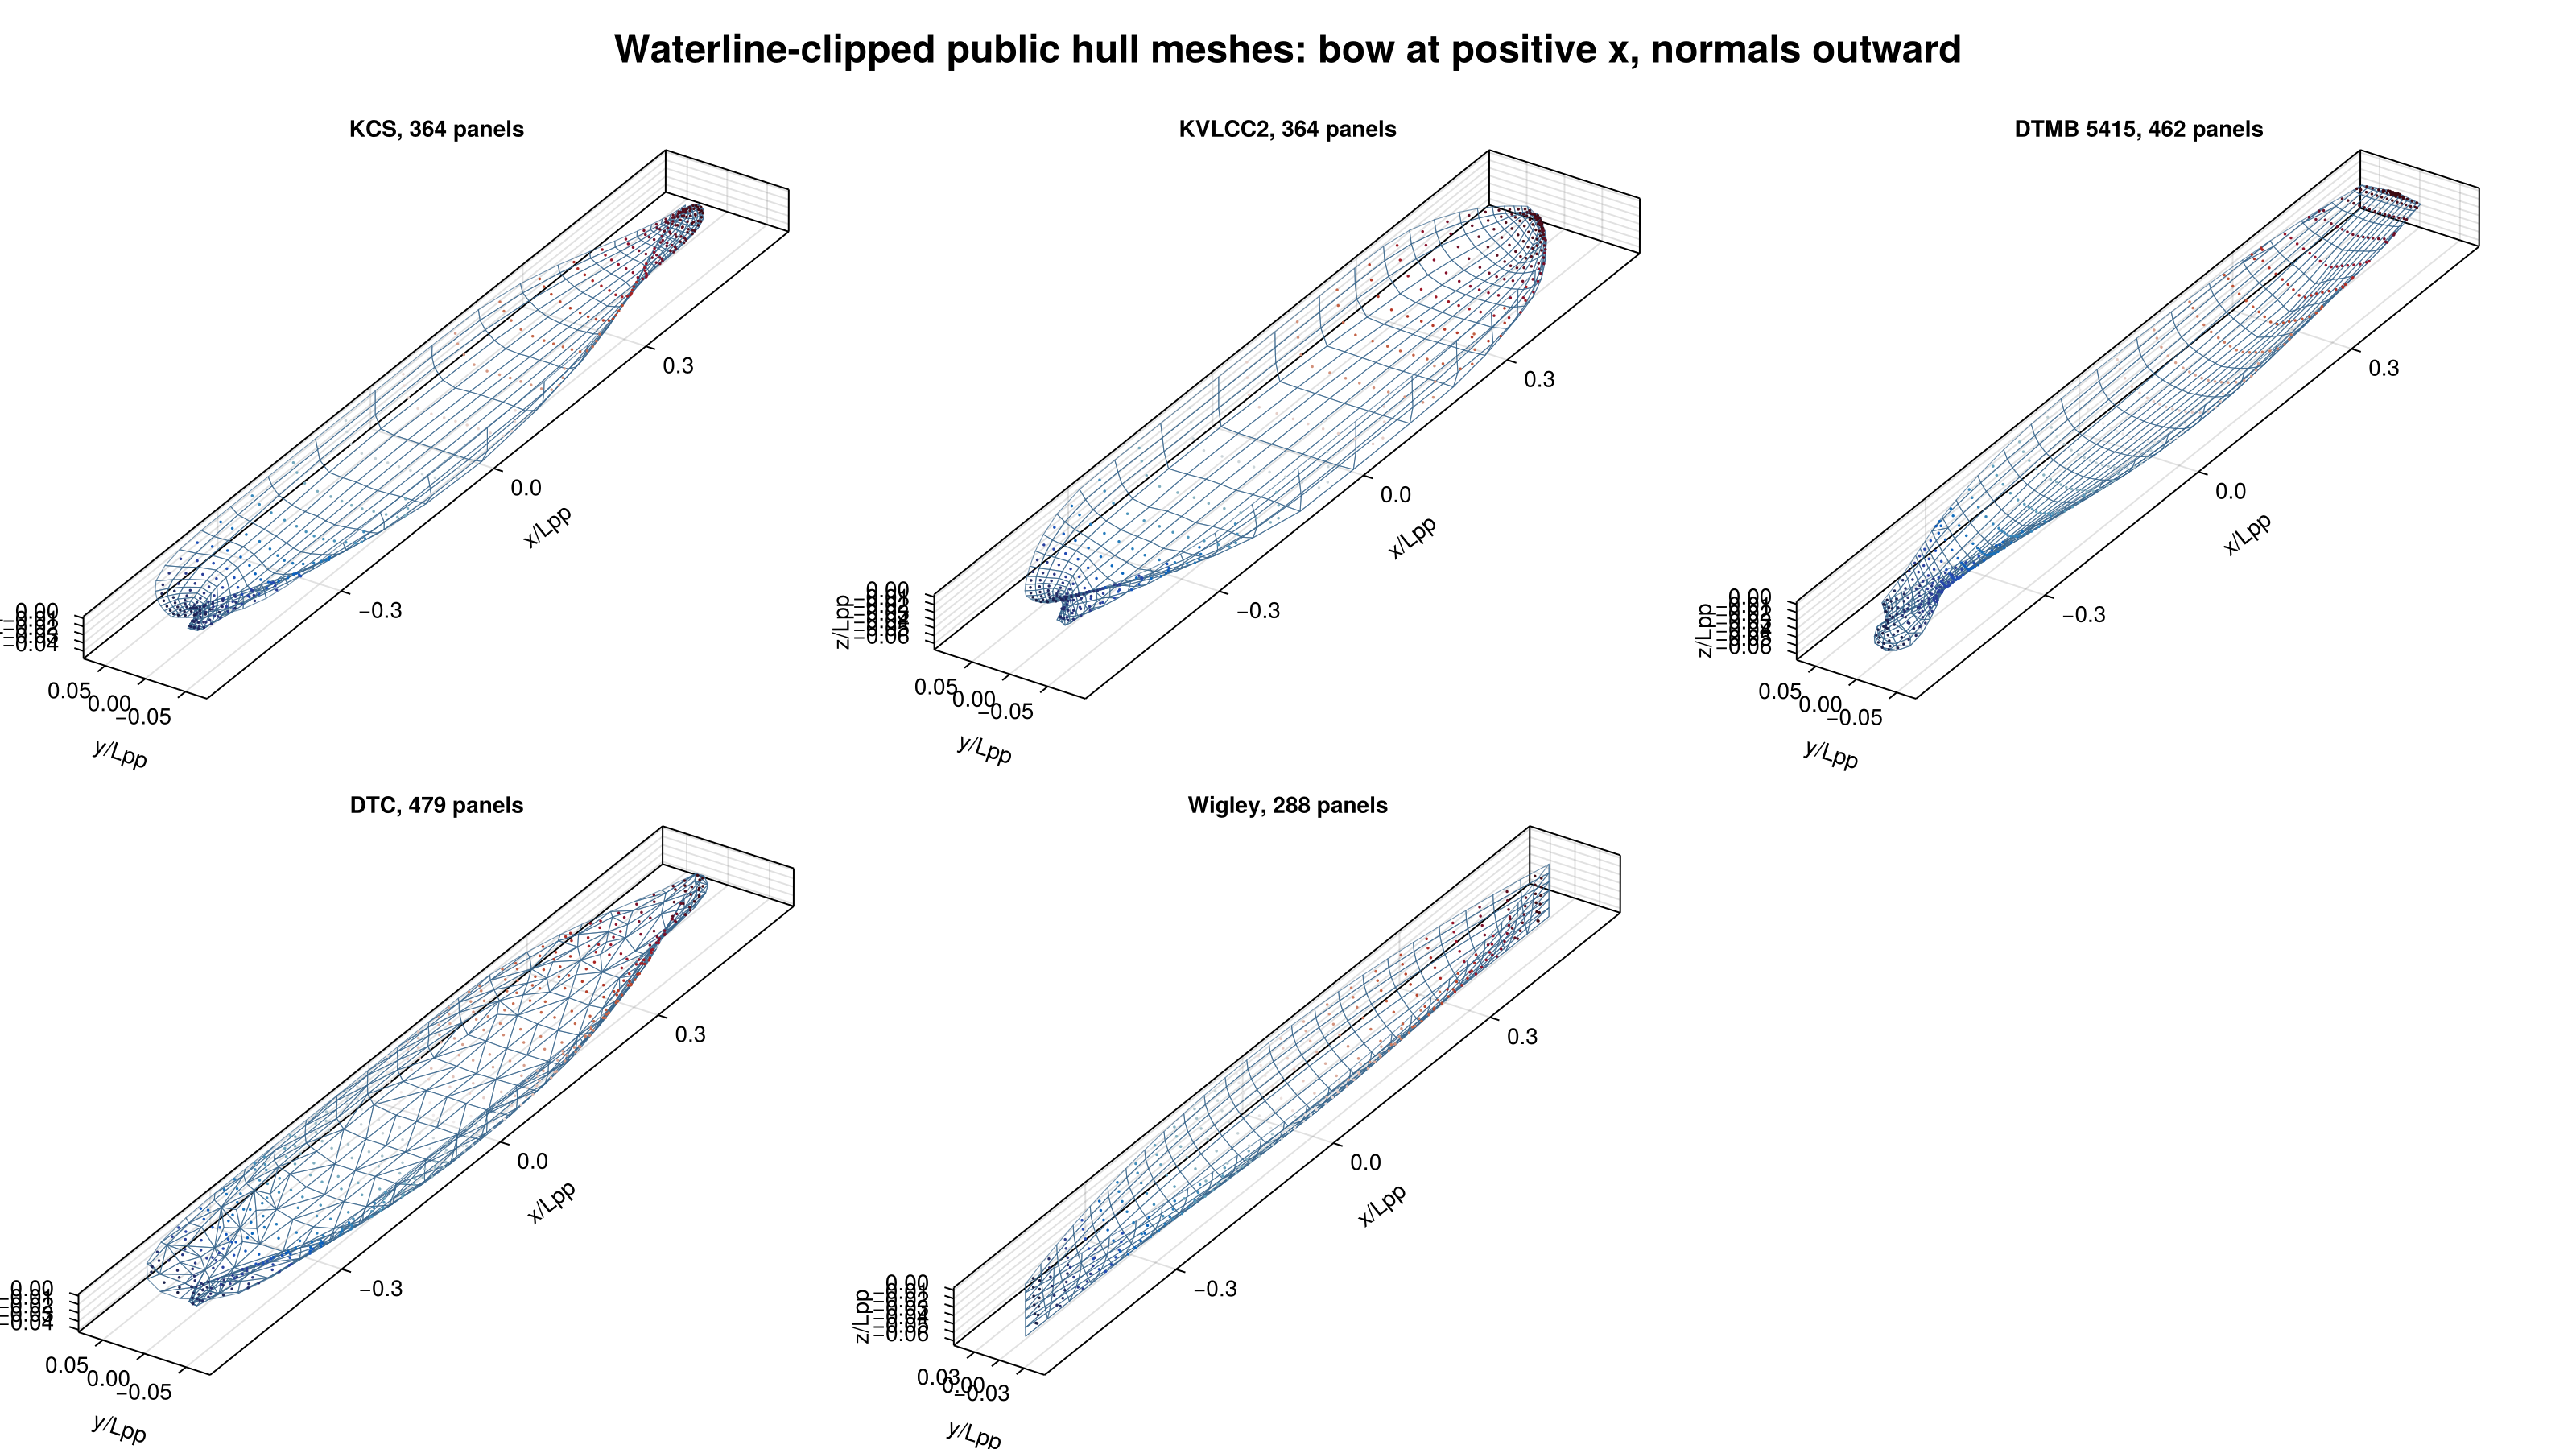

In [4]:
function panel_wireframe(mesh, length_scale)
    x = Float64[]; y = Float64[]; z = Float64[]
    for panel in 1:mesh.nfaces
        indices = mesh.faces[panel, :] .+ 1
        for index in (indices[1], indices[2], indices[3], indices[4], indices[1])
            push!(x, mesh.vertices[index, 1] / length_scale)
            push!(y, mesh.vertices[index, 2] / length_scale)
            push!(z, mesh.vertices[index, 3] / length_scale)
        end
        push!(x, NaN); push!(y, NaN); push!(z, NaN)
    end
    return x, y, z
end

geometry_figure = Figure(size=(1600, 900), backgroundcolor=:white)
for (index, case) in enumerate(cases)
    row = fld(index - 1, 3) + 1
    column = mod(index - 1, 3) + 1
    length_scale = case.reference["length_m"]
    axis = Axis3(geometry_figure[row, column];
        title="$(case.name), $(case.mesh.nfaces) panels",
        xlabel="x/Lpp", ylabel="y/Lpp", zlabel="z/Lpp",
        aspect=:data, azimuth=1.18pi, elevation=0.17pi)
    lines!(axis, panel_wireframe(case.mesh, length_scale)...;
        color=(:steelblue4, 0.72), linewidth=0.55)
    scatter!(axis,
        case.mesh.centers[:, 1] ./ length_scale,
        case.mesh.centers[:, 2] ./ length_scale,
        case.mesh.centers[:, 3] ./ length_scale;
        color=case.mesh.centers[:, 1] ./ length_scale, colormap=:balance,
        markersize=2.5)
end
Label(geometry_figure[0, :],
    "Waterline-clipped public hull meshes: bow at positive x, normals outward";
    fontsize=24, font=:bold)
save(joinpath(results_directory, "public_hull_geometry.png"), geometry_figure;
    px_per_unit=1.5)
geometry_figure

## 3.3 Results

The bars below use the standard MMG scales and the recommended settings
throughout — independent yaw potential, direct-formulation acceleration
derivatives, double-body linearization. Reference markers are captive-test
values where a public one was transcribed, and Kijima's empirical estimate for
Wigley; the full provenance of every reference number, including the ones
marked `NaN`, is in `validation/public_hulls/references.toml`.

The strict-Wang yaw approximation is deliberately **not** overlaid on these
bars. `wang_hydrodynamic_derivatives` reproduces the paper, which means it
also carries the indirect formulation and the uniform-stream linearization, so
a bar-against-bar comparison would show three effects at once. It is isolated
properly in the last panel, with the formulation and linearization held fixed
on both sides. Every variant is still written to the CSV.

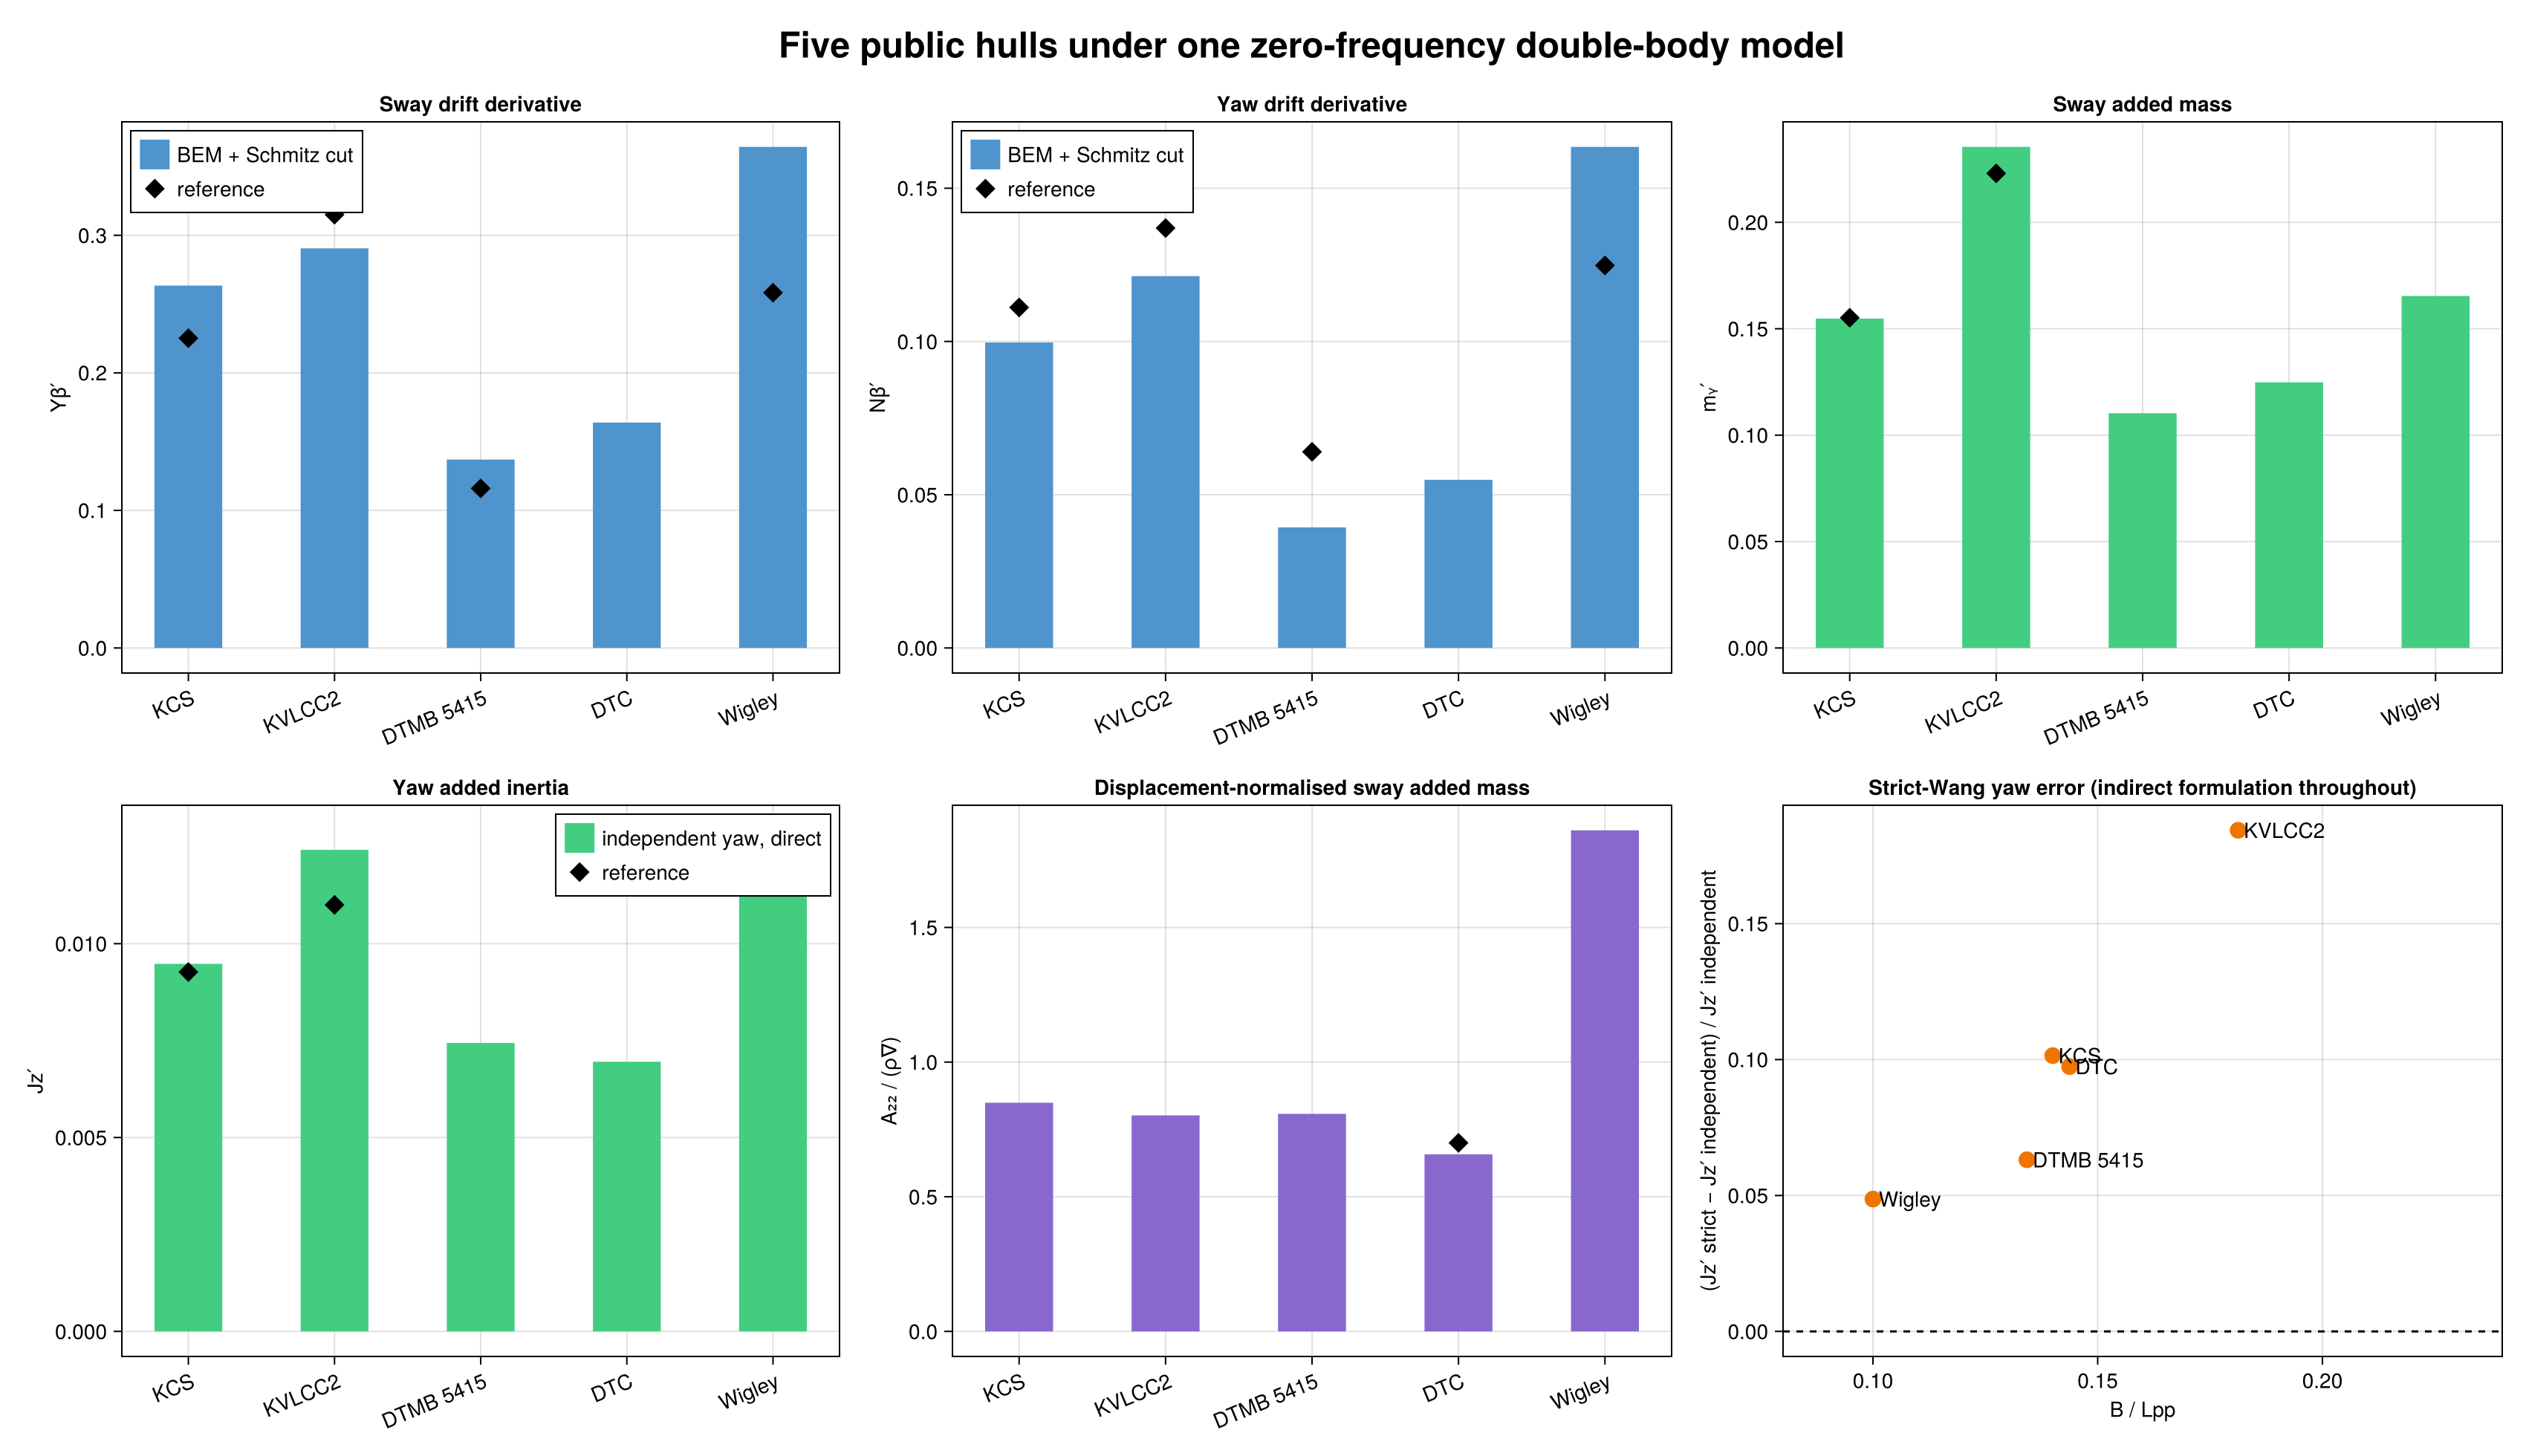

In [5]:
hull_names = [row.hull for row in results]
positions = collect(1:length(results))

figure = Figure(size=(1700, 980), backgroundcolor=:white)

Y_axis = Axis(figure[1, 1]; title="Sway drift derivative", ylabel="Yβ′",
    xticks=(positions, hull_names), xticklabelrotation=pi / 8)
barplot!(Y_axis, positions, [row.Y_beta_mmg for row in results];
    color=:steelblue3, width=0.58, label="BEM + Schmitz cut")
finite_Y = findall(row -> isfinite(row.reference_Y_beta_mmg), results)
scatter!(Y_axis, positions[finite_Y],
    [results[i].reference_Y_beta_mmg for i in finite_Y];
    color=:black, marker=:diamond, markersize=15, label="reference")
axislegend(Y_axis; position=:lt)

N_axis = Axis(figure[1, 2]; title="Yaw drift derivative", ylabel="Nβ′",
    xticks=(positions, hull_names), xticklabelrotation=pi / 8)
barplot!(N_axis, positions, [row.N_beta_mmg for row in results];
    color=:steelblue3, width=0.58, label="BEM + Schmitz cut")
finite_N = findall(row -> isfinite(row.reference_N_beta_mmg), results)
scatter!(N_axis, positions[finite_N],
    [results[i].reference_N_beta_mmg for i in finite_N];
    color=:black, marker=:diamond, markersize=15, label="reference")
axislegend(N_axis; position=:lt)

my_axis = Axis(figure[1, 3]; title="Sway added mass", ylabel="mᵧ′",
    xticks=(positions, hull_names), xticklabelrotation=pi / 8)
barplot!(my_axis, positions, [row.m_y_prime for row in results];
    color=:seagreen3, width=0.58)
finite_my = findall(row -> isfinite(row.reference_m_y_prime), results)
scatter!(my_axis, positions[finite_my],
    [results[i].reference_m_y_prime for i in finite_my];
    color=:black, marker=:diamond, markersize=15)

Jz_axis = Axis(figure[2, 1]; title="Yaw added inertia", ylabel="Jz′",
    xticks=(positions, hull_names), xticklabelrotation=pi / 8)
barplot!(Jz_axis, positions, [row.J_z_prime for row in results];
    color=:seagreen3, width=0.58, label="independent yaw, direct")
finite_Jz = findall(row -> isfinite(row.reference_J_z_prime), results)
scatter!(Jz_axis, positions[finite_Jz],
    [results[i].reference_J_z_prime for i in finite_Jz];
    color=:black, marker=:diamond, markersize=15, label="reference")
axislegend(Jz_axis; position=:rt)

volume_axis = Axis(figure[2, 2]; title="Displacement-normalised sway added mass",
    ylabel="A₂₂ / (ρ∇)", xticks=(positions, hull_names), xticklabelrotation=pi / 8)
barplot!(volume_axis, positions,
    [row.A22_over_rho_displacement for row in results];
    color=:mediumpurple3, width=0.58)
finite_A22 = findall(row -> isfinite(row.reference_A22_over_rho_displacement), results)
scatter!(volume_axis, positions[finite_A22],
    [results[i].reference_A22_over_rho_displacement for i in finite_A22];
    color=:black, marker=:diamond, markersize=15)

# How badly does the slender-body yaw approximation do, and does it track
# slenderness as the theory says it should?
slenderness_axis = Axis(figure[2, 3];
    title="Strict-Wang yaw error (indirect formulation throughout)",
    xlabel="B / Lpp", ylabel="(Jz′ strict − Jz′ independent) / Jz′ independent")
scatter!(slenderness_axis,
    [row.beam_over_length for row in results],
    [row.strict_J_z_relative_difference for row in results];
    color=:darkorange2, markersize=16)
for row in results
    text!(slenderness_axis, row.beam_over_length,
        row.strict_J_z_relative_difference;
        text=" " * row.hull, align=(:left, :center), fontsize=14)
end
hlines!(slenderness_axis, [0.0]; color=:black, linestyle=:dash)
xlims!(slenderness_axis, 0.08, 0.24)

Label(figure[0, :],
    "Five public hulls under one zero-frequency double-body model";
    fontsize=24, font=:bold)
save(joinpath(results_directory, "public_hull_comparison.png"), figure;
    px_per_unit=1.5)
figure

In [6]:
# Full numeric record, written next to the figures in the untracked results
# directory.
output_path = joinpath(results_directory, "public_hull_comparison.csv")
columns = propertynames(first(results))
open(output_path, "w") do io
    println(io, join(columns, ','))
    for row in results
        println(io, join((getproperty(row, column) for column in columns), ','))
    end
end
println("wrote $(output_path)")

# Refresh the tracked regression checkpoint with the columns it records.
checkpoint_columns = (
    :hull, :panels, :volume_relative_error, :A22_over_rho_displacement,
    :A66_over_rho_displacement_length2, :m_y_prime, :reference_m_y_prime,
    :J_z_prime, :reference_J_z_prime, :Y_beta_mmg, :reference_Y_beta_mmg,
    :N_beta_mmg, :reference_N_beta_mmg, :acceleration_reciprocity_error,
)
checkpoint_path = joinpath(validation_directory, "standard_checkpoint.csv")
open(checkpoint_path, "w") do io
    println(io, join(checkpoint_columns, ','))
    for row in results
        println(io, join((getproperty(row, c) for c in checkpoint_columns), ','))
    end
end
println("refreshed $(checkpoint_path)")

wrote c:\Users\iamje\.julia\dev\MarineHydro\validation\public_hulls\results\public_hull_comparison.csv
refreshed c:\Users\iamje\.julia\dev\MarineHydro\validation\public_hulls\standard_checkpoint.csv


## 3.4 Interpretation

**Geometry.** All five hulls close to within about 1 % of their published
displaced volume from four unrelated file formats, and the Wigley hull — where
the target $\nabla=\tfrac49LBT$ is exact — confirms that the residual is
discretization rather than importer error.

**Added mass.** This is where the model deserves to be believed. The
acceleration derivatives come from the direct-formulation solve
(`acceleration_formulation = :direct`), which notebook 1 showed to be roughly
twenty times more accurate than the indirect path on the same mesh, so these
are close to converged rather than benefiting from cancelling errors.

**Strict versus independent yaw.** The final panel is the one to read against
§1.4. The strict approximation $\phi_r\approx x\phi_2$ drops the $-y\,n_x$
term, which should matter more for beamier hulls, and the $J_z'$ discrepancy
does track $B/L_{pp}$ across the set: $4.9\,\%$ for Wigley at $0.100$,
$6.3\,\%$ for DTMB 5415 at $0.134$, $9.7\,\%$ and $10.2\,\%$ for the
effectively tied DTC and KCS at $0.144$ and $0.140$, and $18.4\,\%$ for
KVLCC2 at $0.181$. This is the quantitative justification for
`solve_potential_flow_maneuvering` over `solve_wang_maneuvering`.

This comparison is deliberately evaluated with the **indirect** formulation on
both sides. `solve_potential_flow_maneuvering` now takes its acceleration
derivatives from a direct solve while `wang_hydrodynamic_derivatives` stays
indirect, so comparing them as-is would fold the formulation difference into
what is supposed to measure the yaw-mode approximation alone — and it does so
badly enough to destroy the trend entirely. Isolating one effect at a time
matters here.

**Drift derivatives.** These should be read as a low-order estimate, not a
prediction. Their magnitude is set by the Schmitz cut, which is a fitted
quantity, and they omit the cross-flow drag that dominates real captive-test
slopes. The `acceleration_reciprocity_error` column is the useful internal
diagnostic here: $Y_{\dot r}$ and $N_{\dot v}$ must be equal in the continuum
limit, so its magnitude bounds the discretization error on the acceleration
derivatives independently of any reference data.

### Where this leaves the method

| Quantity | Confidence |
|---|---|
| Hull geometry and volume | High — cross-checked against an analytic hull |
| $A_{22}$, $A_{66}$ | Good — direct formulation, verified to $0.18\,\%$ on the analytic ellipsoid |
| $N_v$ (Munk moment) | Good — the double-body linearization recovers the exact value to $0.08\,\%$ on the ellipsoid |
| $Y_v$ | Not predictive from potential flow: identically zero. Its magnitude comes entirely from the Schmitz cut |
| $Y_r$, $N_r$ | Need a separate rotational truncation station or `clarke_rotational_derivatives` |